## Simulating phase-separated giant unilamellar vesicles (GUVs) with `DeepTrack2`

In [1]:
import functools
import operator

import numpy as np
import deeptrack as dt
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy.ndimage import map_coordinates

np.random.seed(7)

/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/deeptrack/backend/_config.py:200: UserWarning: OpenCV (cv2) is not installed. Some image processing features will be unavailable.
  warnings.warn(


## Helper functions

Optics (one per colour channel), the full-ring membrane, the arc bead-chain, and small utilities.

In [2]:
IMAGE_SIZE = 400
PIXEL_SIZE_UM = 1.0 / 7.0  # resolution (1 um) / magnification (7)

green_optics = dt.Fluorescence(
    wavelength=509e-9, NA=1.2, resolution=1e-6, magnification=7,
    refractive_index_medium=1.33, output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

red_optics = dt.Fluorescence(
    wavelength=665e-9, NA=1.2, resolution=1e-6, magnification=7,
    refractive_index_medium=1.33, output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)


def generate_GUV(position, radius, thickness=0.5e-6, z_radius=0.05e-6, intensity=1.0):
    """A complete, flat membrane ring: a negative disk cancelled by a
    larger positive disk everywhere except the thin annulus between them."""
    inner = dt.Ellipsoid(position=position, radius=(radius, radius, z_radius), intensity=-intensity)
    outer = dt.Ellipsoid(
        position=inner.position,
        radius=(radius + thickness, radius + thickness, z_radius),
        intensity=inner.intensity * -1,
    )
    return inner >> outer


def arc_patches(center_px, radius_um, angle_start_deg, angle_end_deg,
                 patch_radius_um=0.3, spacing_um=0.35, z_radius_um=0.05, intensity=1.0):
    """One arc of membrane, traced by a chain of small overlapping flat
    dt.Ellipsoid 'beads' rather than a single partial-annulus object."""
    arc_length_um = radius_um * np.radians(angle_end_deg - angle_start_deg)
    n_beads = max(2, int(np.ceil(arc_length_um / spacing_um)) + 1)
    angles = np.radians(np.linspace(angle_start_deg, angle_end_deg, n_beads))
    radius_px = radius_um / PIXEL_SIZE_UM
    beads = [
        dt.Ellipsoid(
            position=(center_px[0] + radius_px * np.sin(a), center_px[1] + radius_px * np.cos(a)),
            radius=(patch_radius_um * 1e-6, patch_radius_um * 1e-6, z_radius_um * 1e-6),
            intensity=intensity,
        )
        for a in angles
    ]
    return functools.reduce(operator.rshift, beads)


def membrane_arcs(center_px, radius_um, angle_ranges_deg, **kwargs):
    """Several arcs (e.g. the Lo regions split by three Ld domains),
    combined into one scatterer."""
    pieces = [arc_patches(center_px, radius_um, lo, hi, **kwargs) for lo, hi in angle_ranges_deg]
    return functools.reduce(operator.rshift, pieces)


def complementary_ranges(ranges_deg, full=360):
    """The angle ranges NOT covered by ranges_deg, e.g. the Lo arcs left
    over once the Ld domains are removed from the full circle."""
    ranges_deg = sorted(ranges_deg)
    comp, prev = [], 0
    for lo, hi in ranges_deg:
        if lo > prev:
            comp.append((prev, lo))
        prev = max(prev, hi)
    if prev < full:
        comp.append((prev, full))
    return comp


def render(scatterer, optics):
    return np.squeeze(np.array(optics(scatterer).resolve()))


def normalize(image):
    peak = image.max()
    return np.clip(image / max(peak, 1e-12), 0, 1)


def add_scalebar(ax, length_um=5, color="white"):
    ax.add_artist(AnchoredSizeBar(
        ax.transData, length_um / PIXEL_SIZE_UM, f"{length_um} \u00b5m",
        loc="lower right", pad=0.4, color=color, frameon=False,
        size_vertical=2, fontproperties={"size": 11, "weight": "bold"},
    ))


green_cmap = LinearSegmentedColormap.from_list("lo_green", ["#000000", "#00ff00"])
red_cmap = LinearSegmentedColormap.from_list("ld_red", ["#000000", "#ff0000"])

### Panels A-C: homogeneous vesicles + a colocalised pair

In [3]:
main_pos = (230, 190)
small_positions = [(75, 320), (95, 345)]

green_scene_ac = functools.reduce(operator.and_, [
    generate_GUV(main_pos, radius=9e-6, thickness=0.6e-6, intensity=1.0),
    generate_GUV(small_positions[0], radius=2.6e-6, thickness=0.35e-6, intensity=1.0),
    generate_GUV(small_positions[1], radius=2.6e-6, thickness=0.35e-6, intensity=1.0),
])
red_scene_ac = functools.reduce(operator.and_, [
    generate_GUV(main_pos, radius=9e-6, thickness=0.6e-6, intensity=0.06),
    generate_GUV(small_positions[0], radius=2.6e-6, thickness=0.35e-6, intensity=1.0),
    generate_GUV(small_positions[1], radius=2.6e-6, thickness=0.35e-6, intensity=1.0),
])

green_ac = normalize(render(green_scene_ac, green_optics))
red_ac = normalize(render(red_scene_ac, red_optics))
merge_ac = np.stack([red_ac, green_ac, np.zeros_like(green_ac)], axis=-1)

### Panels D-H: a phase-separated vesicle

In [4]:
center_px = (200, 200)
shell_radius_um = 8.0
shell_radius_px = shell_radius_um / PIXEL_SIZE_UM
domain_angle_ranges = [(160, 205), (250, 280), (300, 330)]  # Ld domains, degrees
lo_angle_ranges = complementary_ranges(domain_angle_ranges)

green_scene_dg = membrane_arcs(center_px, shell_radius_um, lo_angle_ranges, intensity=1.0)
red_scene_dg = membrane_arcs(center_px, shell_radius_um, domain_angle_ranges, intensity=1.0)

green_dg = normalize(render(green_scene_dg, green_optics))
red_dg = normalize(render(red_scene_dg, red_optics))
merge_dg = np.stack([red_dg, green_dg, np.zeros_like(green_dg)], axis=-1)

In [5]:
# Line profile through an Ld domain (~182 deg, inside the 160-205 deg range)
# and the Lo region on the opposite side of the vesicle.
theta = np.radians(182)
direction = np.array([np.sin(theta), np.cos(theta)])  # (row, col)
p0 = np.array(center_px) + 1.3 * shell_radius_px * direction  # starts in the Ld domain
p1 = np.array(center_px) - 1.3 * shell_radius_px * direction  # ends in the Lo region

n_samples = 400
line = np.linspace(p0, p1, n_samples)
green_profile = map_coordinates(green_dg, line.T, order=1)
red_profile = map_coordinates(red_dg, line.T, order=1)
distance_um = np.linspace(0, np.linalg.norm(p1 - p0) * PIXEL_SIZE_UM, n_samples)

### Assemble the figure

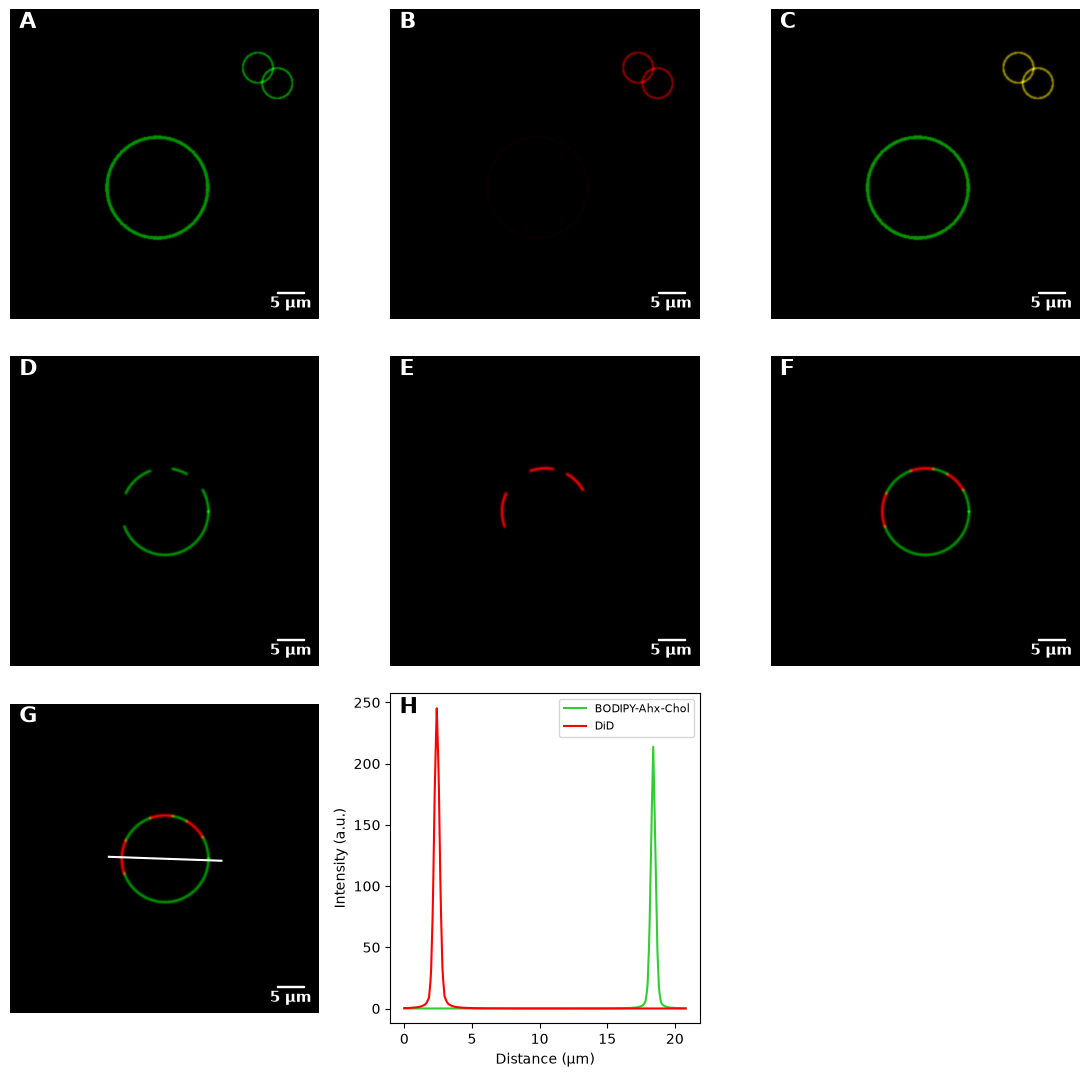

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax in axes.ravel():
    ax.axis("off")

(panelA, panelB, panelC), (panelD, panelE, panelF), (panelG, panelH, blank) = axes
blank.axis("off")


def show(ax, image, cmap, letter):
    ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
    add_scalebar(ax)
    ax.text(0.03, 0.94, letter, transform=ax.transAxes, color="white",
            fontsize=16, fontweight="bold")


def show_merge(ax, image, letter):
    ax.imshow(image)
    add_scalebar(ax)
    ax.text(0.03, 0.94, letter, transform=ax.transAxes, color="white",
            fontsize=16, fontweight="bold")


show(panelA, green_ac, green_cmap, "A")
show(panelB, red_ac, red_cmap, "B")
show_merge(panelC, merge_ac, "C")

show(panelD, green_dg, green_cmap, "D")
show(panelE, red_dg, red_cmap, "E")
show_merge(panelF, merge_dg, "F")

show_merge(panelG, merge_dg, "G")
panelG.plot([p0[1], p1[1]], [p0[0], p1[0]], color="white", lw=1.5)

panelH.axis("on")
panelH.plot(distance_um, green_profile * 255, color="limegreen", label="BODIPY-Ahx-Chol")
panelH.plot(distance_um, red_profile * 255, color="red", label="DiD")
panelH.set_xlabel("Distance (\u00b5m)")
panelH.set_ylabel("Intensity (a.u.)")
panelH.legend(fontsize=8, loc="upper right")
panelH.text(0.03, 0.94, "H", transform=panelH.transAxes, fontsize=16, fontweight="bold")
panelH.annotate("Ld", (distance_um[np.argmax(red_profile)], 260), ha="center", fontweight="bold")
panelH.annotate("Lo", (distance_um[np.argmax(green_profile)], 260), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()